C:\tmp\ipykernel_22192\539774745.py:8: DtypeWarning: Columns (0,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("School_Data_CSV.csv", encoding="cp1252")


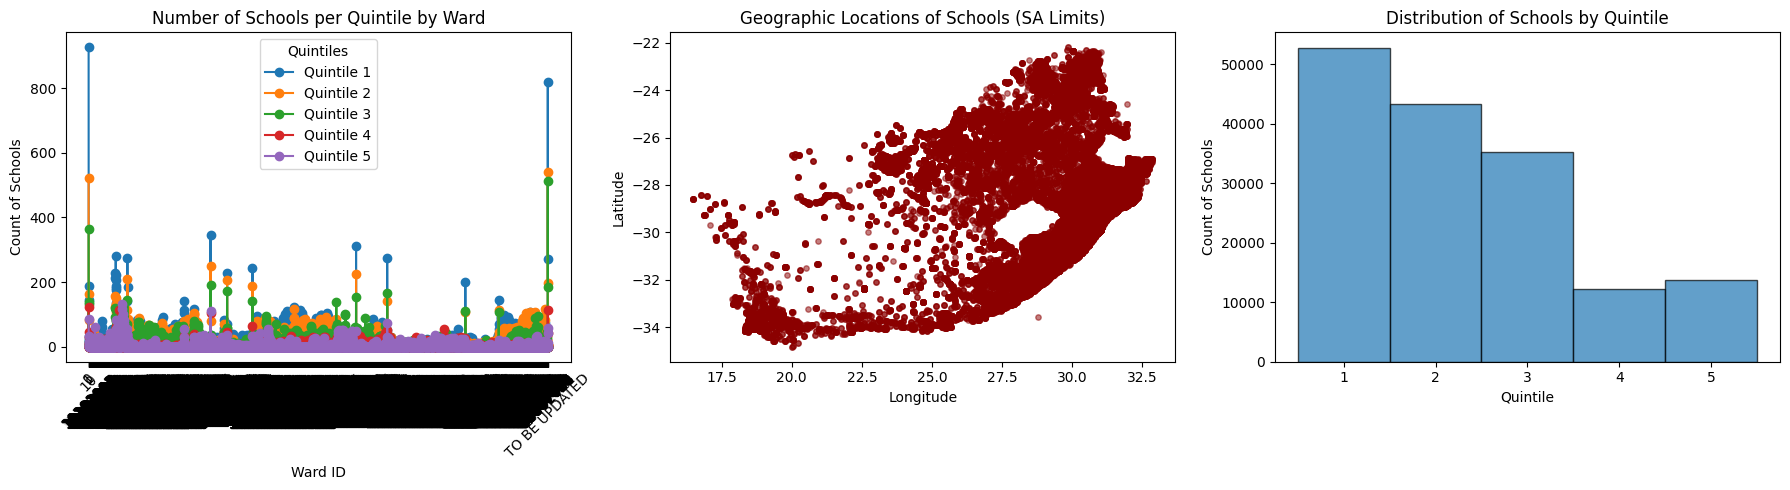

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
# -------------------------------------------------
# Use cp1252 for typical Windows Excel exports
df = pd.read_csv("School_Data_CSV.csv", encoding="cp1252")

# 2. Data Cleaning
# -------------------------------------------------
# Clean the 'quintile' column: 
# Convert to string, uppercase, remove 'Q', and strip whitespace
df['quintile_clean'] = df['quintile'].astype(str).str.upper().str.replace('Q', '').str.strip()

# Keep only the valid numeric quintiles (1 to 5)
valid_quintiles = ['1', '2', '3', '4', '5']
df_q = df[df['quintile_clean'].isin(valid_quintiles)].copy()

# Cast the cleaned quintiles to integer for proper sorting and plotting
df_q['quintile_clean'] = df_q['quintile_clean'].astype(int)

# Clean geographical columns:
# Cast new_long to numeric, coercing non-numeric strings (like "TRUE" or ".") to NaN
df['new_long'] = pd.to_numeric(df['new_long'], errors='coerce')

# Ensure new_lat is numeric, coercing any accidental string artifacts to NaN
df['new_lat'] = pd.to_numeric(df['new_lat'], errors='coerce')

# Filter for South Africa's valid geographic bounding box
df_geo = df[
    (df['new_lat'] >= -35) & (df['new_lat'] <= -22) &
    (df['new_long'] >= 16) & (df['new_long'] <= 33)
].copy()

# 3. Visualizations
# -------------------------------------------------
# Set up a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Line Plot: Schools per quintile across wards
# Group by ward_id and quintile_clean, then unstack to create columns for each quintile
ward_counts = df_q.groupby(['ward_id', 'quintile_clean']).size().unstack(fill_value=0)

for quintile in ward_counts.columns:
    axes[0].plot(
        ward_counts.index.astype(str), # Ensure ward IDs plot as categorical strings 
        ward_counts[quintile], 
        marker='o', 
        label=f'Quintile {quintile}'
    )

axes[0].set_title('Number of Schools per Quintile by Ward')
axes[0].set_xlabel('Ward ID')
axes[0].set_ylabel('Count of Schools')
axes[0].tick_params(axis='x', rotation=45) # Rotate ward labels for readability
axes[0].legend(title='Quintiles')

# b) Scatter Plot: Geographic locations
axes[1].scatter(df_geo['new_long'], df_geo['new_lat'], alpha=0.5, s=15, color='darkred')
axes[1].set_title('Geographic Locations of Schools (SA Limits)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

# c) Histogram: Distribution of schools by quintile
# We use bins aligned to the discrete 1-5 integers so the bars center correctly over the numbers
axes[2].hist(df_q['quintile_clean'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor='black', alpha=0.7)
axes[2].set_title('Distribution of Schools by Quintile')
axes[2].set_xlabel('Quintile')
axes[2].set_ylabel('Count of Schools')
axes[2].set_xticks([1, 2, 3, 4, 5])

# Adjust layout to prevent overlap
plt.tight_layout()

# 4. Save Figures
# -------------------------------------------------
# Define the output directory
output_dir = "genAI_model_2_figures"

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save the figure to the directory
output_path = os.path.join(output_dir, "school_visualizations.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')

# Display the plot
plt.show()